In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('delhiaqi.csv')

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

df.head()

Shape: (561, 9)

Columns:
Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB
None

Missing Values:
date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

Duplicate Rows:
0


In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['Hour'] = df['date'].dt.hour
df['Day'] = df['date'].dt.day
df['Month'] = df['date'].dt.month

df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,Hour,Day,Month
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83,0,1,1
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66,1,1,1
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40,2,1,1
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55,3,1,1
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19,4,1,1


In [ ]:
df[['date','Hour','Day','Month']].head()

,date,Hour,Day,Month
0,2023-01-01 00:00:00,0,1,1
1,2023-01-01 01:00:00,1,1,1
2,2023-01-01 02:00:00,2,1,1
3,2023-01-01 03:00:00,3,1,1
4,2023-01-01 04:00:00,4,1,1


In [ ]:
df['AQI'] = df[['pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co']].mean(axis=1)

df[['date', 'AQI']].head()

,date,AQI
0,2023-01-01 00:00:00,347.116667
1,2023-01-01 01:00:00,388.240000
2,2023-01-01 02:00:00,510.821667
3,2023-01-01 03:00:00,631.520000
4,2023-01-01 04:00:00,691.720000


In [ ]:
def classify_aqi(aqi):
    if aqi <= 33:
        return "Very Good"
    elif aqi <= 66:
        return "Good"
    elif aqi <= 99:
        return "Fair"
    elif aqi <= 149:
        return "Poor"
    elif aqi <= 200:
        return "Very Poor"
    else:
        return "Dangerous"

In [ ]:
df['AQI_Category'] = df['AQI'].apply(classify_aqi)

df[['AQI', 'AQI_Category']].head()

,AQI,AQI_Category
0,347.116667,Dangerous
1,388.240000,Dangerous
2,510.821667,Dangerous
3,631.520000,Dangerous
4,691.720000,Dangerous


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

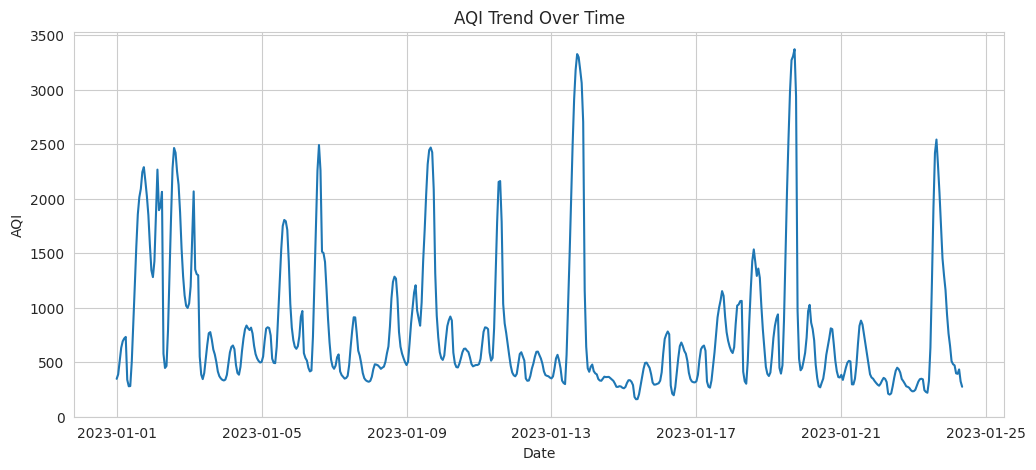

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['date'], df['AQI'])

plt.title('AQI Trend Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')

plt.show()

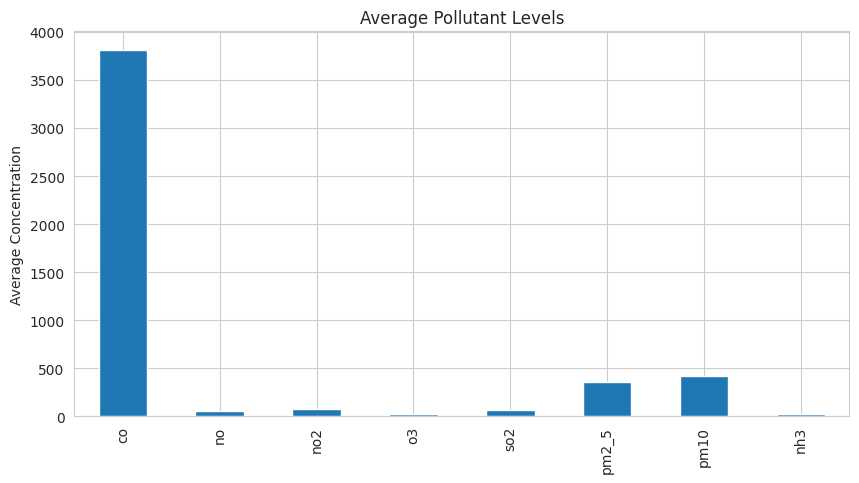

In [ ]:
pollutants = ['co','no','no2','o3','so2','pm2_5','pm10','nh3']

avg_pollutants = df[pollutants].mean()

plt.figure(figsize=(10,5))

avg_pollutants.plot(kind='bar')

plt.title('Average Pollutant Levels')
plt.ylabel('Average Concentration')

plt.show()

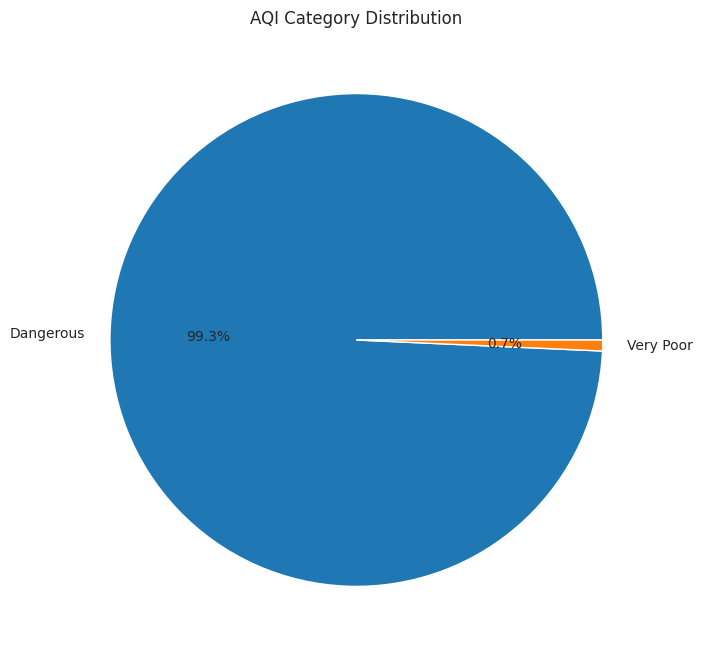

In [ ]:
aqi_counts = df['AQI_Category'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(aqi_counts,
        labels=aqi_counts.index,
        autopct='%1.1f%%')

plt.title('AQI Category Distribution')

plt.show()

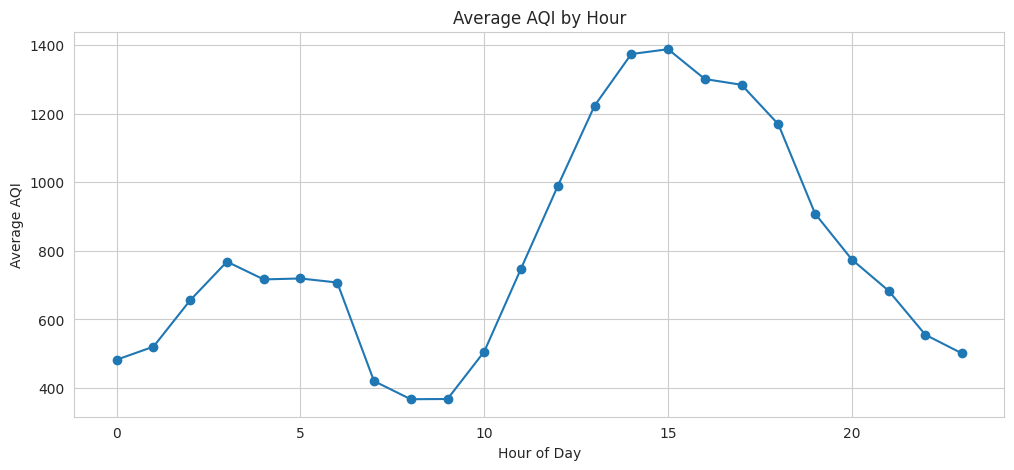

In [ ]:
hourly_aqi = df.groupby('Hour')['AQI'].mean()

plt.figure(figsize=(12,5))

hourly_aqi.plot(kind='line', marker='o')

plt.title('Average AQI by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average AQI')

plt.show()

In [ ]:
top_polluted = df.nlargest(10, 'AQI')

top_polluted[['date','AQI']]

,date,AQI
449,2023-01-19 17:00:00,3372.581667
305,2023-01-13 17:00:00,3327.930000
448,2023-01-19 16:00:00,3308.568333
306,2023-01-13 18:00:00,3299.521667
447,2023-01-19 15:00:00,3272.543333
307,2023-01-13 19:00:00,3185.583333
304,2023-01-13 16:00:00,3182.850000
308,2023-01-13 20:00:00,3062.546667
446,2023-01-19 14:00:00,2987.196667
450,2023-01-19 18:00:00,2940.668333


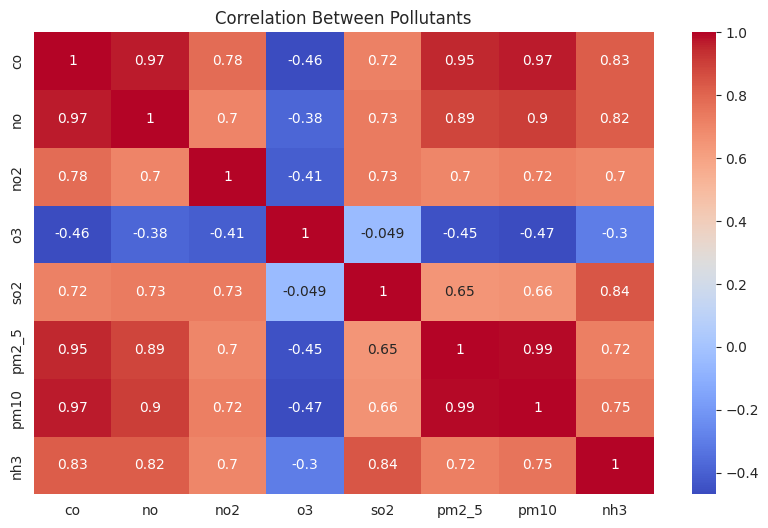

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Pollutants')

plt.show()